# 05 - EDA Soporte Y Churn

## Hipotesis iniciales

1. Mas contactos con soporte anticipan mayor riesgo de churn porque reflejan friccion o problemas no resueltos.
2. Incidencias no resueltas y baja satisfaccion post-contacto deberian incrementar la probabilidad de churn futuro.
3. Los motivos de contacto permiten separar problemas accionables: impago, cobertura, facturacion, averias o gestion comercial.
4. El canal principal puede capturar diferencias en urgencia, esfuerzo del cliente o tipo de problema.
5. Para modelar correctamente, soporte debe agregarse a cliente-mes usando solo interacciones ocurridas hasta el mes `t`.

## Que se va a contrastar

- Evolucion mensual del volumen de contactos y satisfaccion.
- Churn futuro por numero de contactos, no resueltos y satisfaccion.
- Motivos y canales con mayor tasa de churn posterior.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.float_format = '{:,.3f}'.format

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELING = PROJECT_ROOT / 'data' / 'modeling'
REPORTS = PROJECT_ROOT / 'reports'

soporte = pd.read_csv(PROCESSED / 'interacciones_soporte_clean.csv', parse_dates=['fecha_evento', 'mes'])
churn = pd.read_csv(PROCESSED / 'churn_target_clean.csv', parse_dates=['fecha'])
churn = churn.sort_values(['cliente_id', 'fecha'])
churn['churn_t_plus_1'] = churn.groupby('cliente_id')['churn'].shift(-1)
base = churn.dropna(subset=['churn_t_plus_1'])[['cliente_id', 'fecha', 'churn_t_plus_1']]
agg = soporte.groupby(['cliente_id', 'mes'], as_index=False).agg(
    contactos=('interaccion_id', 'count'),
    no_resueltos=('resuelto', lambda x: int((x == 0).sum())),
    satisfaccion_media=('satisfaccion_post', 'mean'),
    duracion_media=('duracion_min', 'mean'),
    impago_mes=('impago_mes', 'max'),
    motivo_principal=('motivo', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Desconocido'),
    canal_principal=('canal', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Desconocido')
).rename(columns={'mes': 'fecha'})
df = base.merge(agg, on=['cliente_id', 'fecha'], how='left')
df['churn_t_plus_1'] = df['churn_t_plus_1'].astype(int)
df['contactos'] = df['contactos'].fillna(0)
df['no_resueltos'] = df['no_resueltos'].fillna(0)


In [2]:
display(soporte.head())
display(df.head())


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes,motivo_was_missing,duracion_min_was_invalid,satisfaccion_post_was_missing
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.500,0,4.000,0.410,0,0,0,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.900,1,4.000,0.430,0,0,0,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.800,1,5.000,0.430,0,0,0,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.400,1,3.000,0.449,0,0,0,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.500,1,4.000,0.394,0,0,0,0,0,0


,cliente_id,fecha,churn_t_plus_1,contactos,no_resueltos,satisfaccion_media,duracion_media,impago_mes,motivo_principal,canal_principal
0,C000001,2023-01-01,0,0.000,0.000,NaN,NaN,NaN,NaN,NaN
1,C000001,2023-02-01,0,1.000,1.000,4.000,9.500,0.000,Facturación,telefono
2,C000001,2023-03-01,0,0.000,0.000,NaN,NaN,NaN,NaN,NaN
3,C000001,2023-04-01,0,2.000,0.000,4.500,3.350,0.000,Baja / portabilidad,app_chat
4,C000001,2023-05-01,0,1.000,0.000,3.000,8.400,0.000,Consulta general,telefono


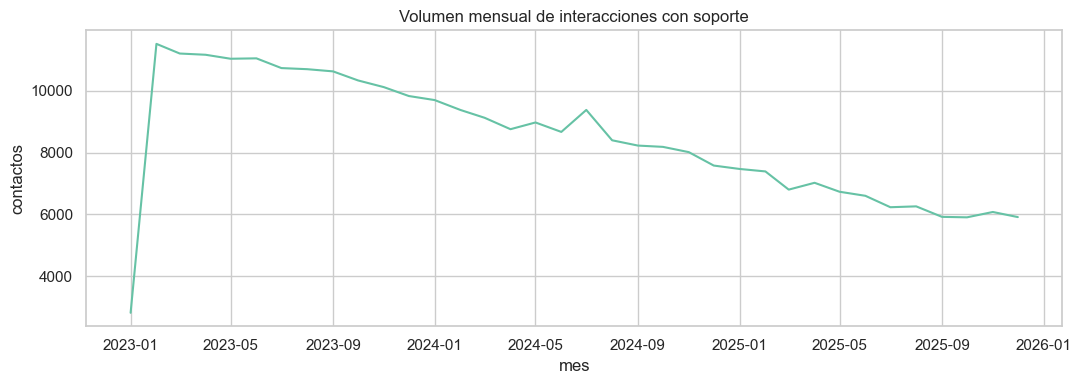

In [3]:
monthly = soporte.groupby('mes', as_index=False).agg(contactos=('interaccion_id','count'), satisfaccion=('satisfaccion_post','mean'))
plt.figure(figsize=(11, 4))
sns.lineplot(data=monthly, x='mes', y='contactos')
plt.title('Volumen mensual de interacciones con soporte')
plt.tight_layout()
plt.show()


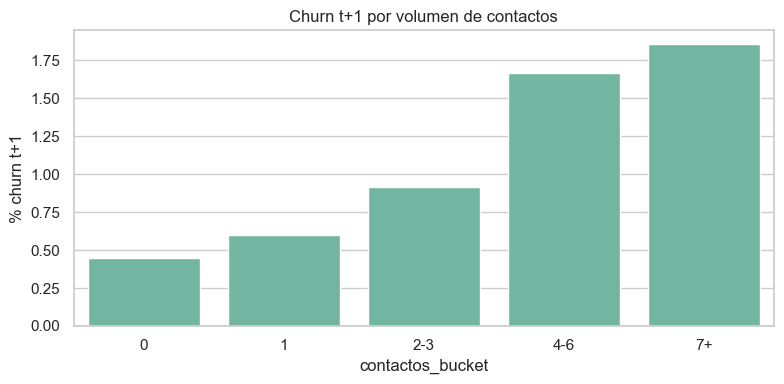

In [4]:
df['contactos_bucket'] = pd.cut(df['contactos'], bins=[-1, 0, 1, 3, 6, 100], labels=['0', '1', '2-3', '4-6', '7+'])
rates = df.groupby('contactos_bucket')['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
rates['churn_rate'] *= 100
plt.figure(figsize=(8, 4))
sns.barplot(data=rates, x='contactos_bucket', y='churn_rate')
plt.title('Churn t+1 por volumen de contactos')
plt.ylabel('% churn t+1')
plt.tight_layout()
plt.show()


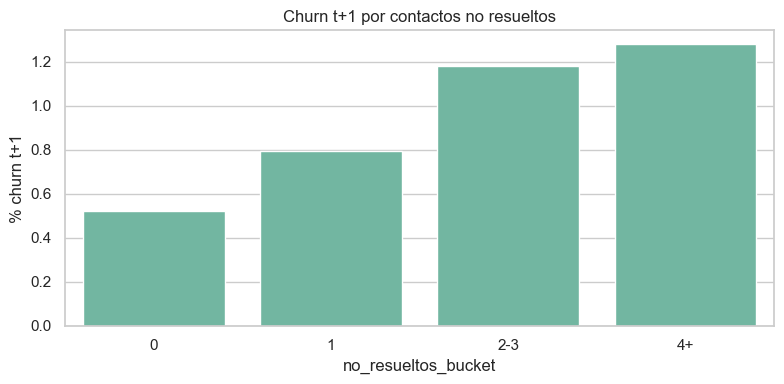

In [5]:
df['no_resueltos_bucket'] = pd.cut(df['no_resueltos'], bins=[-1, 0, 1, 3, 100], labels=['0', '1', '2-3', '4+'])
rates = df.groupby('no_resueltos_bucket')['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
rates['churn_rate'] *= 100
plt.figure(figsize=(8, 4))
sns.barplot(data=rates, x='no_resueltos_bucket', y='churn_rate')
plt.title('Churn t+1 por contactos no resueltos')
plt.ylabel('% churn t+1')
plt.tight_layout()
plt.show()


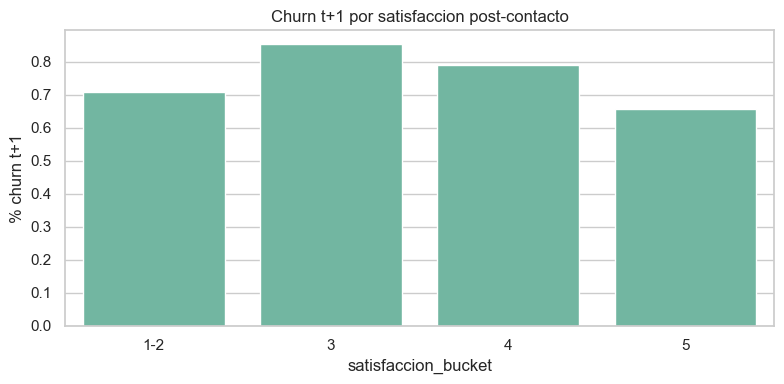

In [6]:
plot_df = df[df['contactos'] > 0].copy()
plot_df['satisfaccion_bucket'] = pd.cut(plot_df['satisfaccion_media'], bins=[0, 2, 3, 4, 5], labels=['1-2', '3', '4', '5'])
rates = plot_df.groupby('satisfaccion_bucket')['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
rates['churn_rate'] *= 100
plt.figure(figsize=(8, 4))
sns.barplot(data=rates, x='satisfaccion_bucket', y='churn_rate')
plt.title('Churn t+1 por satisfaccion post-contacto')
plt.ylabel('% churn t+1')
plt.tight_layout()
plt.show()


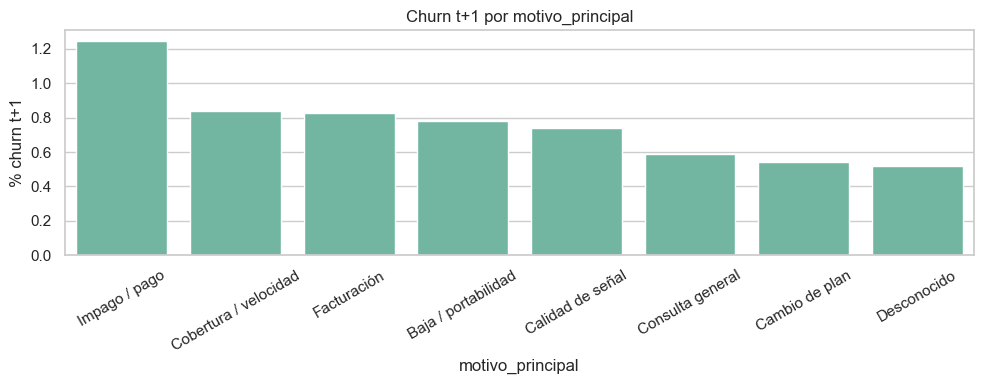

,motivo_principal,n,churn_rate
7,Impago / pago,18863,1.246
3,Cobertura / velocidad,25834,0.840
6,Facturación,16048,0.829
0,Baja / portabilidad,24561,0.782
1,Calidad de señal,45133,0.738
4,Consulta general,30609,0.588
2,Cambio de plan,11090,0.541
5,Desconocido,1916,0.522


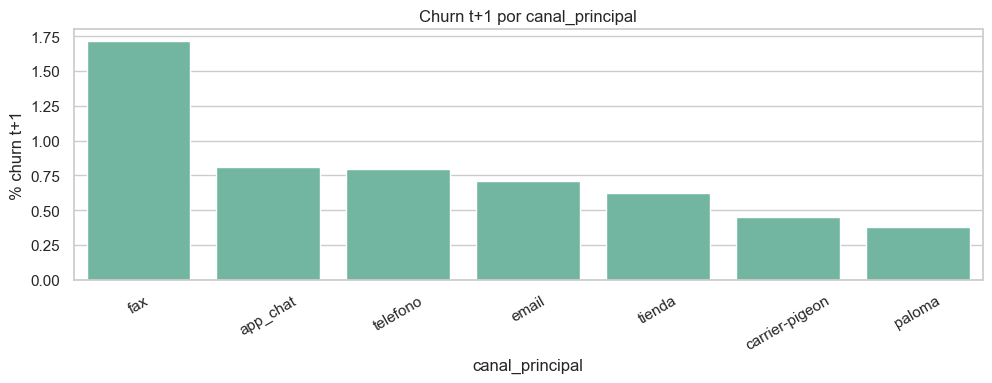

,canal_principal,n,churn_rate
3,fax,759,1.713
0,app_chat,74422,0.810
5,telefono,70534,0.794
2,email,13162,0.707
6,tienda,13489,0.623
1,carrier-pigeon,894,0.447
4,paloma,794,0.378


In [7]:
for col in ['motivo_principal', 'canal_principal']:
    rates = plot_df.groupby(col)['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
    rates['churn_rate'] *= 100
    rates = rates.sort_values('churn_rate', ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(data=rates, x=col, y='churn_rate')
    plt.title(f'Churn t+1 por {col}')
    plt.ylabel('% churn t+1')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    display(rates)


## Conclusiones finales

- Soporte es una familia de variables claramente accionable: volumen de contactos, no resueltos y satisfaccion pueden convertirse en alertas operativas.
- Los buckets de contactos y no resueltos permiten detectar si el riesgo aumenta con acumulacion de fricciones, mas alla de una unica llamada aislada.
- La satisfaccion post-contacto es importante porque resume experiencia percibida despues de una interaccion critica.
- Los motivos muestran diferencias utiles para negocio: en la salida revisada `Impago / pago` aparece con una tasa de churn superior a otros motivos, alrededor del 1.246%.
- La informacion de soporte debe agregarse con cuidado temporal; usar interacciones posteriores al mes `t` generaria leakage.

## Decisiones para feature engineering

- Crear conteos mensuales de contactos por cliente.
- Crear rolling de 3 meses para contactos, no resueltos y satisfaccion.
- Usar motivo y canal principal del mes como categoricas.
- Crear indicadores de existencia de contacto y de incidencia no resuelta.
- Mantener soporte como familia separada para medir su aportacion incremental al modelo.
